# Verification

## Building Blocks

In [1]:
import numpy as np
from numpy.polynomial import Chebyshev, Polynomial, chebyshev
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from scipy.linalg import null_space, block_diag
from qiskit.circuit.library import UnitaryGate


In [2]:
verbose = True
np.set_printoptions(precision=4)

### Setting

In [3]:
dim = 4
S = np.arange(dim)

# Basis
eye = np.identity(dim)
basis = np.asarray([row.reshape(-1,1) for row in eye])

# Markov kernel P
P = np.asarray([[1/2, 1/2, 0, 0],
                [1/4, 1/2, 1/4, 0],
                [0, 1/4, 1/2, 1/4],
                [0, 0, 1/2, 1/2]], dtype=float)
if verbose: print(f"Markov kernel: \n{P}")

# Stationary distribution
pi = np.asarray([1/6, 1/3, 1/3, 1/6])

assert np.allclose(P.sum(axis=1), 1.0), "The rows of P don't sum to 1. P is not a Markov Kernel"
assert np.allclose(pi @ P, pi), "pi is not the stationary distribution of P"

if verbose: print(f"\nStationary distribution: \n{pi}")

# State of stationary distribution
pi_state = np.sqrt(pi).reshape(-1, 1)
if verbose: print(f"\nState of stationary distribution:\n{pi_state}")

# Reversibility
for x in range(dim):
    for y in range(dim):
        assert np.allclose(pi[x] * P[x, y], pi[y] * P[y, x]), (f"Detailed balance fails at x={x}, y={y}.")

if verbose: print(f"\nDetailed balance verified.")


Markov kernel: 
[[0.5  0.5  0.   0.  ]
 [0.25 0.5  0.25 0.  ]
 [0.   0.25 0.5  0.25]
 [0.   0.   0.5  0.5 ]]

Stationary distribution: 
[0.1667 0.3333 0.3333 0.1667]

State of stationary distribution:
[[0.4082]
 [0.5774]
 [0.5774]
 [0.4082]]

Detailed balance verified.


### Discriminant
We define the discriminant matrix.

We compute the leading eigenvalue and verify it is 1, since it is a reversible Markov chain.

We compute the spectral gap.

In [4]:
# Discriminant
D = np.zeros((4,4))
for x in range(dim):
    for y in range(dim):
        D[x,y] = np.sqrt(pi[x]/pi[y]) * P[x][y]
if verbose: print(f"Discriminant: \n{D}")

if verbose: 
    if not (np.allclose(D @ D.conj().T, np.identity(D.shape[0])) and np.allclose(D.conj().T @ D, np.identity(D.shape[-1]))):
        print(f"\nD is not unitary.")

# Leading eigenvalue of the discriminant
evals, evecs = np.linalg.eigh(D)

idx = evals.argsort()[::-1]

sorted_evals = evals[idx]
sorted_evecs = evecs[:, idx]
if verbose: print(f"\nSorted eigenvalues: {evals}")

leading_eval, leading_evec = sorted_evals[0], sorted_evecs[:, 0]
if verbose: print(f"\nLeading eigenvalue: {leading_eval}")
if verbose: print(f"\nLeading eigenvector:\n {leading_evec}")

assert np.allclose(leading_eval, 1.0), "Leading value is not 1."

# Spectral gap
second_eval = sorted_evals[1]
spectral_gap = leading_eval - second_eval
print(f"\nSpectral gap: {spectral_gap:.2f}")


Discriminant: 
[[0.5    0.3536 0.     0.    ]
 [0.3536 0.5    0.25   0.    ]
 [0.     0.25   0.5    0.3536]
 [0.     0.     0.3536 0.5   ]]

D is not unitary.

Sorted eigenvalues: [-1.013e-16  2.500e-01  7.500e-01  1.000e+00]

Leading eigenvalue: 1.0

Leading eigenvector:
 [0.4082 0.5774 0.5774 0.4082]

Spectral gap: 0.25


### SPUE
We construct the partial isometry (square) and the swap matrix (S).

We verify (square, S) is a SPUE of the discriminant.

In [5]:
# Partial isometry
square = np.zeros((dim * dim, dim))
for x in range(dim):
    for y in range(dim):
        square += np.sqrt(P[x][y]) * np.kron(basis[x], basis[y]) @ basis[x].conj().T

assert np.allclose(square.conj().T @ square, np.identity(square.shape[-1])), "square is not a partial isometry."
if verbose: print(f"Partial isometry:\n{square}")

# Swap
swap = np.zeros((dim * dim, dim * dim))
for x in range(dim):
    for y in range(dim):
        swap += np.kron(basis[x], basis[y]) @ np.kron(basis[y].conj().T, basis[x].conj().T)
if verbose: print(f"\nSwap matrix:\n{swap}")

# SPUE
spue = square.conj().T @ swap @ square

assert np.allclose(D, spue), "(square, swap) is not a SPUE of D"

Partial isometry:
[[0.7071 0.     0.     0.    ]
 [0.7071 0.     0.     0.    ]
 [0.     0.     0.     0.    ]
 [0.     0.     0.     0.    ]
 [0.     0.5    0.     0.    ]
 [0.     0.7071 0.     0.    ]
 [0.     0.5    0.     0.    ]
 [0.     0.     0.     0.    ]
 [0.     0.     0.     0.    ]
 [0.     0.     0.5    0.    ]
 [0.     0.     0.7071 0.    ]
 [0.     0.     0.5    0.    ]
 [0.     0.     0.     0.    ]
 [0.     0.     0.     0.    ]
 [0.     0.     0.     0.7071]
 [0.     0.     0.     0.7071]]

Swap matrix:
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0

### Reflection and Qubitized Walk Operator

We build the reflection operator R of D.

We build the qubitized walk operator W of D. We verify it is unitary. We need it to be unitary to use GQSP (I think?).

In [6]:
# Reflection Operator
projector = square @ square.conj().T
R = 2 * projector - np.identity(square.shape[0]) # (16, 16)

assert np.allclose(projector @ projector, projector), ("square square^dagger is not a projector.")

if verbose: print(f"Reflection operator:\n{R}")

# Qubitized Walk
W = R @ swap # (16, 16)

assert np.allclose(W.conj().T @ W, np.eye(W.shape[-1])), ("W is not unitary.")

if verbose: print(f"Qubitized walk operator:\n{W}")
if verbose: print(f"W is unitary.")

Reflection operator:
[[ 2.2204e-16  1.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
 [ 1.0000e+00  2.2204e-16  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
 [ 0.0000e+00  0.0000e+00 -1.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
 [ 0.0000e+00  0.0000e+00  0.0000e+00 -1.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00 -5.0000e-01  7.0711e-01
   5.0000e-01  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00  0.0000e+

## GQET - Generalized Quantum Eigenvalue Transformation

### Chebyshev Polynomial

We set epsilon=0.125 (we could try different values later to try decreasing the degree of the polynomial).

We calculate the minimum degree d of the Chebyshev polynomial.

In [7]:
# "Allowed error"
epsilon = 0.125

# Degree pf the polynomial
d_raw = np.arccosh(1/epsilon) / np.arccosh(1 / (1 - spectral_gap))
d = int(np.ceil(d_raw))

if verbose: print(f"Degree of the polynomial (float): {d_raw}")
if verbose: print(f"Degree of the polynomial (upper int): {d}")


Degree of the polynomial (float): 3.480990209272064
Degree of the polynomial (upper int): 4


We define the polynomial to select the leading eigenvalue of D.

In [8]:
alpha = np.cosh(np.arccosh(1 / epsilon) / d)
delta_d = 1 - 1 / alpha

assert delta_d <= spectral_gap + 1e-12, ("The chosen degree is not large enough: delta_d > spectral_gap.")

x_poly = Polynomial([0.0, alpha]) # we build alpha * x
nu_power = epsilon * Chebyshev.basis(d)(x_poly) # epsilon * T_d(alpha * x)

# Convert to chebyshex basis
nu = nu_power.convert(kind=Chebyshev)

# Coefficients that nu and the signal polynomial share a1, ...
coef = nu.coef

if verbose: print(f"Coefficients:\n{coef}")


Coefficients:
[0.258  0.     0.4375 0.     0.3045]


We apply the polynomial directly to D (this cannot happen in a quantum computer since we don't have access to D, D not unitary). 

In [9]:
def cheby_rec(degree, matrix):
    if degree == 0:
        return np.identity(matrix.shape[0])
    elif degree == 1:
        return matrix
    else:
        return 2 * matrix @ cheby_rec(degree - 1, matrix) - cheby_rec(degree - 2, matrix)

In [10]:
assert np.allclose(cheby_rec(0, D), np.identity(D.shape[0])), 'degree 0'
assert np.allclose(cheby_rec(1, D), D), 'degree 1'
assert np.allclose(cheby_rec(2, D), 2 * D @ D - np.identity(D.shape[0])), 'degree 2'
assert np.allclose(cheby_rec(3, D), 4 * D @ D @ D - 3 * D), 'degree 3'
assert np.allclose(cheby_rec(4, D), 8 * D @ D @ D @ D - 8 * D @ D + np.identity(D.shape[0])), 'degree 4'


In [11]:
nu_D = np.zeros_like(D)

for i, a in enumerate(coef):
    nu_D += a * cheby_rec(i, D)

if verbose: print(f"nu(D):\n{nu_D}")

nu(D):
[[0.2058 0.2017 0.2523 0.1522]
 [0.2017 0.3841 0.2949 0.2523]
 [0.2523 0.2949 0.3841 0.2017]
 [0.1522 0.2523 0.2017 0.2058]]


We check that nu(D) ~ |pi><pi|

We check that the leading eigenvalue of nu(D) is close to 1.

We check that the rest of the eigenvalues of nu(D) are smaller than the allowed error epsilon.

In [12]:
projector_stationary = pi_state @ pi_state.conj().T

filter_error = np.linalg.norm(nu_D - projector_stationary, ord=2)

if verbose:
    print(f"\n|pi><pi|:\n{projector_stationary.real}")
    print(f"\n||nu(D) - |pi><pi|||_2 = {filter_error}")

assert filter_error <= epsilon + 1e-10, ("nu(D) is not close enough to the projector onto the stationary distribution.")

if verbose: print("\nnu(D) is close to the projection onto the stationary distribution.")

# Check leading eigenvalue of nu(D) is 1
filtered_evals = chebyshev.chebval(sorted_evals, coef)

if verbose:
    print(f"\nEigenvalues of D:\n{sorted_evals}")
    print(f"\nFiltered eigenvalues nu(lambda):\n{filtered_evals}")

assert np.allclose(filtered_evals[0], 1.0), 'nu(leading_eval) should be 1 by construction.'
if verbose: print(f"\nThe leading eigenvalue of nu(D) is close to 1.")

# Check rest of the eigenvalues
max_filtered_nonleading = np.max(np.abs(filtered_evals[1:]))

assert max_filtered_nonleading <= epsilon + 1e-10, 'At least one of the rest of the eigenvalues is not smaller than epsilon.'
if verbose: print(f"\nThe rest of the eigenvalues of nu(D) are smaller than the allowed error epsilon.")



|pi><pi|:
[[0.1667 0.2357 0.2357 0.1667]
 [0.2357 0.3333 0.3333 0.2357]
 [0.2357 0.3333 0.3333 0.2357]
 [0.1667 0.2357 0.2357 0.1667]]

||nu(D) - |pi><pi|||_2 = 0.12499999999999999

nu(D) is close to the projection onto the stationary distribution.

Eigenvalues of D:
[ 1.000e+00  7.500e-01  2.500e-01 -1.013e-16]

Filtered eigenvalues nu(lambda):
[1.     0.0178 0.037  0.125 ]

The leading eigenvalue of nu(D) is close to 1.

The rest of the eigenvalues of nu(D) are smaller than the allowed error epsilon.


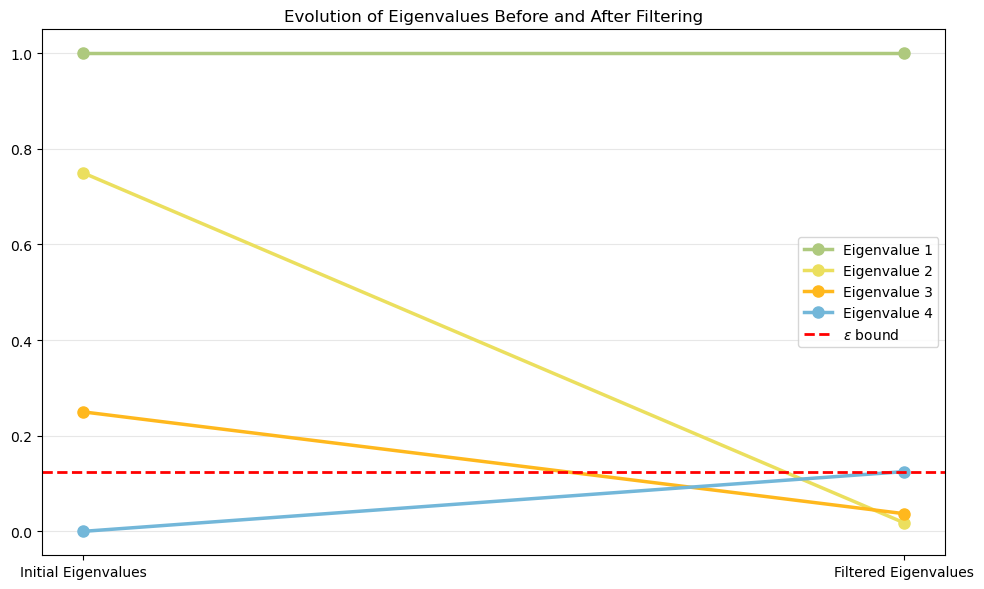

In [13]:
x_labels = ['Initial Eigenvalues', 'Filtered Eigenvalues']

colors = ['#aec97e', '#ebdf5e', '#ffb81d', '#73b7d9'] 

plt.figure(figsize=(10, 6))

for i in range(len(sorted_evals)):
    y_values = [sorted_evals[i], filtered_evals[i]]
    
    plt.plot(x_labels, y_values, marker='o', markersize=8, color=colors[i], 
             linewidth=2.5, label=f'Eigenvalue {i+1}')

plt.axhline(y=epsilon, color='red', linestyle='--', linewidth=2, label='$\epsilon$ bound')

plt.title('Evolution of Eigenvalues Before and After Filtering')
plt.grid(True, axis='y', alpha=0.3)
plt.legend(loc='best')

# Display the plot
plt.tight_layout()
plt.show()

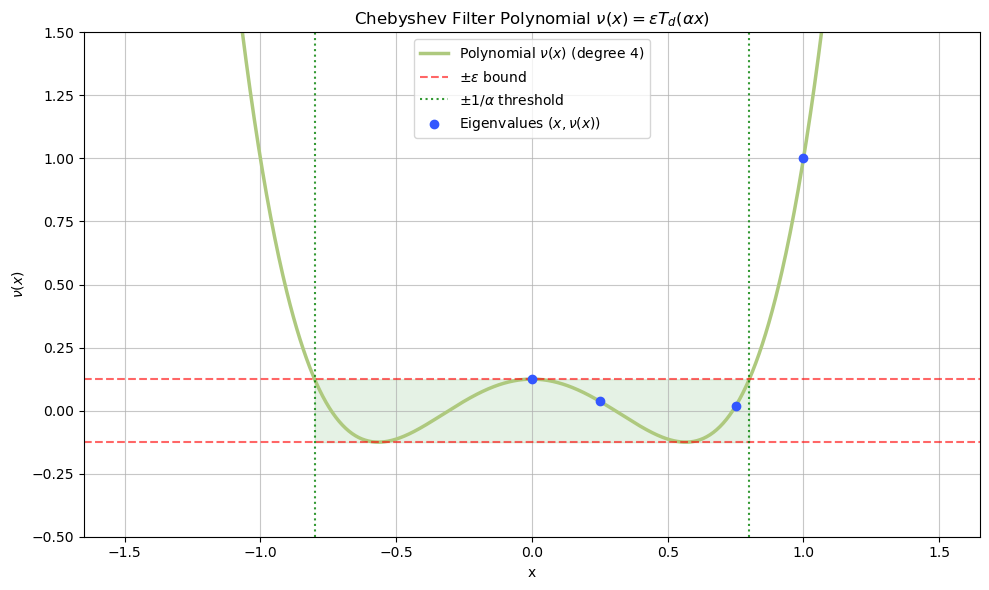

In [14]:
x_vals = np.linspace(-1.5, 1.5, 1000)
y_vals = nu(x_vals)

plt.figure(figsize=(10, 6))

plt.plot(x_vals, y_vals, label=f'Polynomial $\\nu(x)$ (degree {d})', color='#aec97e', linewidth=2.5)

# Epsilon bounds
plt.axhline(epsilon, color='red', linestyle='--', alpha=0.6, label='$\pm\epsilon$ bound')
plt.axhline(-epsilon, color='red', linestyle='--', alpha=0.6)

# Region that has to be less than epsilon
bound_x = 1 / alpha
plt.axvline(bound_x, color='green', linestyle=':', alpha=0.8, label='$\pm 1/\\alpha$ threshold')
plt.axvline(-bound_x, color='green', linestyle=':', alpha=0.8)

plt.fill_between(x_vals, -epsilon, epsilon, 
                 where=(np.abs(x_vals) <= bound_x), 
                 color='green', alpha=0.1)

# Plot eigenvalues
y_evals = nu(sorted_evals)
plt.scatter(sorted_evals, y_evals, color='#3357FF', zorder=5, label='Eigenvalues $(x, \\nu(x))$')

plt.title('Chebyshev Filter Polynomial $\\nu(x) = \epsilon T_d(\\alpha x)$')
plt.xlabel('x')
plt.ylabel('$\\nu(x)$')
plt.ylim(-0.5, 1.5)
plt.grid(True, alpha=0.7)
plt.legend(loc='best')

plt.tight_layout()
plt.show()

### GQSP - Generalized Quantum Signal Processing

We start simply verifying that square_dagger @ Upsilon(W) @ square = nu(D).

In [15]:
# Signal processing polynomial
upsilon_W = np.zeros_like(W)
power = np.identity(W.shape[0])

for c in coef:
    upsilon_W += c * power
    power = power @ W

nu_D_walk = square.conj().T @ upsilon_W @ square

assert np.allclose(nu_D_walk, nu_D), 'nu(D) through W is NOT the same as applying nu(D)'
if verbose: print("nu(D) through W is the same as applying nu(D).")
if verbose: print(f"\nnu_D through W:\n{nu_D_walk}")

nu(D) through W is the same as applying nu(D).

nu_D through W:
[[0.2058 0.2017 0.2523 0.1522]
 [0.2017 0.3841 0.2949 0.2523]
 [0.2523 0.2949 0.3841 0.2017]
 [0.1522 0.2523 0.2017 0.2058]]


# Quantum Circuit

Ordering problem. Qiskit uses little-endian: the LSB is saved at position 0.

## Registries
We build a circuit with the following quantum registries:
- x: 2 qubits (state register)
- y: 2 qubits (transition register)
- s: 1 qubit (GQSP)

and classical registries:
- cx: 2 qubits
- y: 2 qubits
- s: 1 qubit

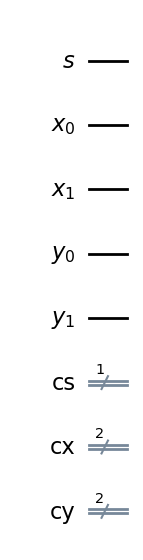

In [16]:
# Quantum registers
qs = QuantumRegister(1, "s")
qx = QuantumRegister(2, "x")
qy = QuantumRegister(2, "y")

# Classical registers
cs = ClassicalRegister(1, "cs")
cx = ClassicalRegister(2, "cx")
cy = ClassicalRegister(2, "cy")

# Quantum circuit
qc = QuantumCircuit(qs, qx, qy, cs, cx, cy)

qc.draw("mpl")

We initialize:
- s --> |0>
- x --> uniform superposition (it is important that the initial state is not orthogonal to the state of the stationary distribution)
- y --> |00>

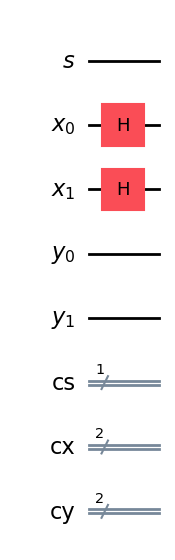

In [17]:
qc.h(qx[0])
qc.h(qx[1])

qc.draw('mpl')

**==>** State of the circuit: |0> |u> |00> = 0.5 * sum_x{|0> |x> |00>}

## Partial Isometry 
In order to apply the partial isometry in a circuit, we need it to be unitary.

We build V = sum_{x}{|x><x| tensor V_x!>}.

V_x is built to be a unitary with the first column equal to |psi_x>

V_x|0> = |psi_x>

In [18]:
# Function to build V_x such that it is unitary and its first column is |psi_x>
def complete_vector_to_unitary(v, atol=1e-12):
    """
    Given a normalized vector v in C^n, build a unitary U
    whose first column is v.
    """
    v = np.asarray(v, dtype=complex).reshape(-1, 1)
    n = v.shape[0]

    norm = np.linalg.norm(v)
    assert np.allclose(norm, 1.0, atol=atol), f"Input vector is not normalized. Norm = {norm}"

    # Find an orthonormal basis of the orthogonal complement of v.
    # This returns an n x (n-1) matrix Q such that v^dagger Q = 0.
    complement = null_space(v.conj().T)

    U = np.hstack([v, complement])

    assert np.allclose(U.conj().T @ U, np.eye(n), atol=atol), "Completion failed: U is not unitary."

    assert np.allclose(U[:, 0], v[:, 0], atol=atol), "First column is not the requested vector."

    return U


# Function to build V, controlled V_x
def build_controlled_unitary_extension(P, atol=1e-12):
    """
    Build V = sum_x |x><x| tensor V_x,
    where V_x |0> = sum_y sqrt(P[x,y]) |y>.
    """
    P = np.asarray(P, dtype=float)
    dim = P.shape[0]

    assert P.shape == (dim, dim), "P must be square."

    assert np.allclose(P.sum(axis=1), 1.0, atol=atol), "Rows of P must sum to 1."

    blocks = []

    for x in range(dim):
        psi_x = np.sqrt(P[x, :]).astype(complex)
        V_x = complete_vector_to_unitary(psi_x, atol=atol)
        blocks.append(V_x)

    V = block_diag(*blocks)

    assert np.allclose(V.conj().T @ V, np.eye(dim * dim), atol=atol), "V is not unitary."

    return V, blocks

In [19]:
V, V_blocks = build_controlled_unitary_extension(P)

if verbose: 
    print(f"Shape of V: {V.shape}")
    print(f"\nUnitary extension of square:\n{V}")
    for i, V_x in enumerate(V_blocks):
        print(f"\nBlock V_{i}:\n{V_x}")


Shape of V: (16, 16)

Unitary extension of square:
[[ 0.7071+0.j -0.7071-0.j  0.    -0.j  0.    -0.j  0.    +0.j  0.    +0.j
   0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j
   0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j]
 [ 0.7071+0.j  0.7071-0.j  0.    -0.j  0.    -0.j  0.    +0.j  0.    +0.j
   0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j
   0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  0.    -0.j  1.    -0.j  0.    -0.j  0.    +0.j  0.    +0.j
   0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j
   0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  0.    -0.j  0.    -0.j  1.    -0.j  0.    +0.j  0.    +0.j
   0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j
   0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.5   +0.j -0.7071-0.j
  -0.5   -0.j  0.    -0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j
   0.

In [20]:
for x in range(dim):
    input_col = dim * x + 0
    assert np.allclose(V[:, input_col], square[:, x])

print("V correctly extends square.")

V correctly extends square.


Since our ordering is big-endian and the one used by Qiskit is little-endian we neet to apply a permutation to build the correct gate for V.

In [21]:
def math_to_qiskit_permutation(dim=4):
    """
    Mathematical ordering:
        |x,y> -> dim*x + y

    Qiskit ordering for qubits [x[0], x[1], y[0], y[1]]:
        |x,y> -> x + dim*y
    """
    N = dim * dim
    Perm = np.zeros((N, N), dtype=complex)

    for x_state in range(dim):
        for y_state in range(dim):
            math_index = dim * x_state + y_state
            qiskit_index = x_state + dim * y_state
            Perm[qiskit_index, math_index] = 1.0

    return Perm

In [22]:
perm = math_to_qiskit_permutation(dim)
V_qiskit = perm @ V @ perm.conj().T

assert np.allclose(V_qiskit.conj().T @ V_qiskit, np.eye(16)), "V is not unitary."
if verbose: print(f"V with little-endian ordering:\n{V_qiskit}")

V with little-endian ordering:
[[ 0.7071+0.j  0.    +0.j  0.    +0.j  0.    +0.j -0.7071+0.j  0.    +0.j
   0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j
   0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  0.5   +0.j  0.    +0.j  0.    +0.j  0.    +0.j -0.7071+0.j
   0.    +0.j  0.    +0.j  0.    +0.j -0.5   +0.j  0.    +0.j  0.    +0.j
   0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j
  -0.5   +0.j  0.    +0.j  0.    +0.j  0.    +0.j -0.7071+0.j  0.    +0.j
   0.    +0.j  0.    +0.j -0.5   +0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j
   0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j -0.7071+0.j
   0.    +0.j  0.    +0.j  0.    +0.j -0.7071+0.j]
 [ 0.7071+0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.7071+0.j  0.    +0.j
   0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j  0.    +0.j
   0.    +0.j  0.    +0.j

We apply the gate of V to the registry x and y.

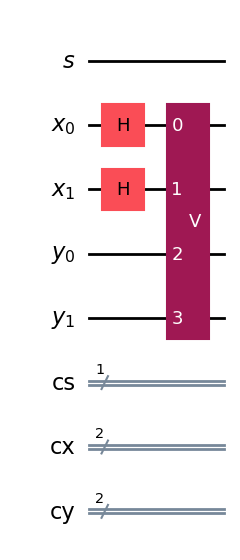

In [23]:
V_gate = UnitaryGate(V_qiskit, label="V")
qc.append(V_gate, list(qx) + list(qy))

qc.draw("mpl")

**==>** State of the circuit: 0.5 * sum_x{|0> |x> |psi_x>}